# Computing Scenarios

This notebook builds the workflow to analyse different insurance coverage scenarios

Ideas for Extensions:
- How much lower premiums you could take at the same profit

## Imports

In [1]:
## So that if you change sth in a src script you don't have to restart the kernel
%load_ext autoreload
%autoreload 2

In [2]:
## Imports
## Allowing for Imports from src folder
import sys
sys.path.append("..") # Adds the project root to the path

In [3]:
## Getting hazard Dict
from src.data_hazard import get_haz_dict

## TODO: Enable Floods!
haz_dict = get_haz_dict()

haz_dict.keys()

dict_keys(['TC', 'TP', 'HL'])

In [4]:
from src.data_exposure import get_exposure

hazard_types = list(haz_dict.keys())

exposure_poly = get_exposure(hazard_types=hazard_types)

exposure_poly_gdf = exposure_poly.gdf

exposure_poly_gdf.head()

,DDEP_C_COD,DDEP_L_LIB,DREG_L_LIB,value,area,insurance,impf_TC,impf_TP,impf_HL,geometry
0,01,Ain,Auvergne-Rhône-Alpes,0.199,5762.4,0.30,1,1,1,"POLYGON ((6.16845 46.36746, 6.16668 46.37074, ..."
1,02,Aisne,Hauts-de-France,0.532,7361.7,0.32,1,1,1,"POLYGON ((4.25573 49.90398, 4.23694 49.90378, ..."
2,03,Allier,Auvergne-Rhône-Alpes,0.170,7340.1,0.30,1,1,1,"POLYGON ((4.00456 46.32748, 3.99436 46.32765, ..."
3,04,Alpes-de-Haute-Provence,Provence-Alpes-Côte d'Azur,0.025,6925.2,0.18,1,1,1,"POLYGON ((6.96709 44.62287, 6.9539 44.63783, 6..."
4,05,Hautes-Alpes,Provence-Alpes-Côte d'Azur,0.017,5548.7,0.18,1,1,1,"POLYGON ((7.07587 44.68512, 7.07424 44.69209, ..."


## Computing Relative Impact

In [5]:
import climada.util.lines_polys_handler as u_lp

# Don't make Resolution too Small!
exposure_pnt = u_lp.exp_geom_to_pnt(
    exposure_poly,
    res=1000,
    to_meters=True,
    disagg_met=u_lp.DisaggMethod.FIX,
    disagg_val=None,
)

exposure_pnt_gdf = exposure_pnt.gdf

In [6]:
from src.helpers import comp_impact

exposure_pnt_gdf["eai"] = comp_impact(
    haz_dict=haz_dict,
    exposure_pnt_gdf=exposure_pnt_gdf
)

Computing TC
Computing TP
Computing HL
2026-04-24 18:11:29,572 - climada.util.coordinates - WARNING - Distance to closest centroid is greater than 0.000237 degree for 548477 coordinates.


## Plotting Impact Maps

In [11]:
from src.helpers import agg_to_departement

impact_poly_gdf = agg_to_departement(
    exposure_pnt_gdf,
    value_cols=["value", "eai"]
)

impact_poly_gdf["rel_damaged_area"] = impact_poly_gdf["eai"] * impact_poly_gdf["value"]

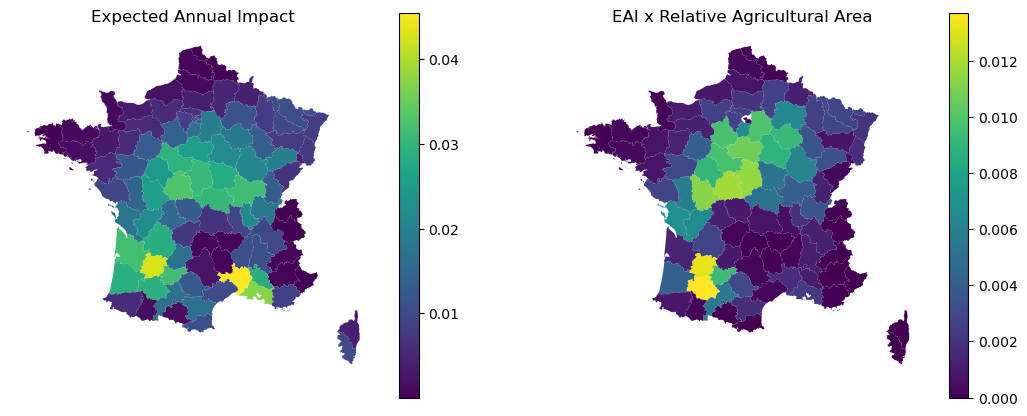

In [15]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 2,
                        figsize=(13, 5))

axs[0].set_title("Expected Annual Impact")
impact_poly_gdf.plot(
    column="eai",
    ax=axs[0],
    cmap="viridis",
    legend=True
)

axs[1].set_title("EAI x Relative Agricultural Area")
impact_poly_gdf.plot(
    column="rel_damaged_area",
    ax=axs[1],
    cmap="viridis",
    legend=True
)

for ax in axs:
    ax.set_axis_off()
    
plt.show()

## Computing Scenarios

In [17]:
from src.scenario_helpers import comp_scenarios

scenarios_dict = comp_scenarios(exposure_pnt_gdf=exposure_pnt_gdf)

## Plotting Scenario Overview

In [32]:
insurance_scaling_factors = []
insured_area = []
who_pays = {"F": [], "I": [], "G": []}

for label, scenario in scenarios_dict.items():
    insurance_scaling_factors.append(label)
    insured_area.append(scenario["insured_area"])
    
    for k in who_pays:
        who_pays[k].append(scenario["who_pays_what"][k])
        
        
total_area = scenarios_dict[0]["scenario_poly"]["area"].sum()
relative_insured_area = insured_area / total_area

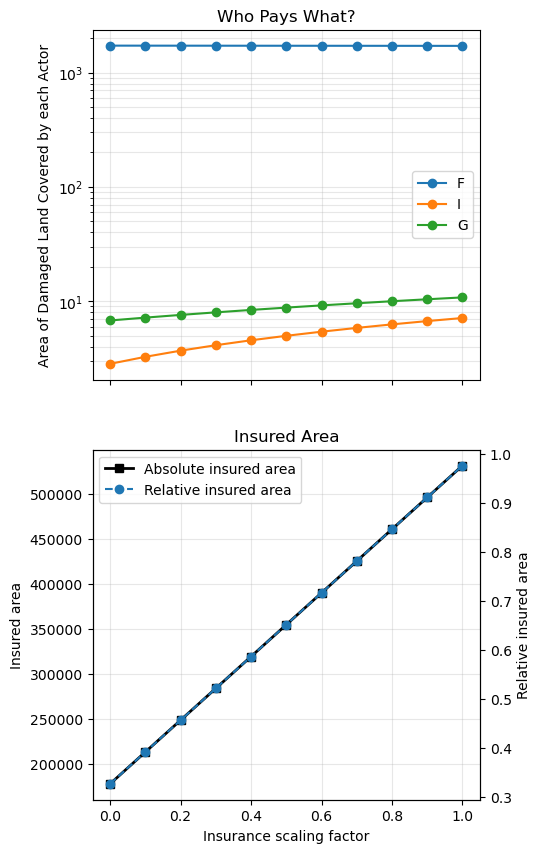

In [34]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(2, 1,
                      figsize = (5, 10),
                      sharex=True)

ax = axs[0]
ax.set_title("Who Pays What?")
ax.set_ylabel("Area of Damaged Land Covered by each Actor")
ax.set_yscale('log')

for label, values in who_pays.items():
    axs[0].plot(
            insurance_scaling_factors,
            values,
            marker="o",
            label=label)

ax.legend()


ax = axs[1]

# Original insured area (left y-axis)
ax.set_title("Insured Area")
ax.plot(
    insurance_scaling_factors,
    insured_area,
    color="black",
    linewidth=2,
    marker="s",
    label="Absolute insured area"
)

ax.set_ylabel("Insured area")
ax.set_xlabel("Insurance scaling factor")

# ---- secondary y-axis on the right ----
ax_right = ax.twinx()
ax_right.plot(
    insurance_scaling_factors,
    relative_insured_area,
    color="tab:blue",
    linestyle="--",
    marker="o",
    label="Relative insured area"
)

ax_right.set_ylabel("Relative insured area")

# ---- combined legend ----
lines_left, labels_left = ax.get_legend_handles_labels()
lines_right, labels_right = ax_right.get_legend_handles_labels()
ax.legend(lines_left + lines_right, labels_left + labels_right, loc="best")


for ax in axs:
    ax.grid(True, which="both", alpha=0.3)

plt.show()

## Plotting Example Scnearios

> myb create plot scenario function